In [18]:
from turbo_ddcm import bit_stream_lex_enc, utils

In [20]:
K = 16384
M = 114
C = 1
B = 0

bit_stream_lex_enc_ = bit_stream_lex_enc.BitStreamEncoder(K, M, C, B)

Loading combination table from /home/amit.vaisman/other_papers_code/Diffusion-Compression-Editing-Attacks/Turbo-DDCM-master/turbo_ddcm/combs_files/comb_K16384_M114.pkl
Combination table loaded successfully


In [16]:
encoding_a = utils.load_binary('../results/noisy_channel/turbo_ddcm/dataset_Kodak24/compressed/dataset_Kodak24_turbo_ddcm_bpp0.1/1.turbo_ddcm')

In [16]:
encoding_b = utils.load_binary('../results2/noisy_channel/turbo_ddcm/dataset_Kodak24/compressed/dataset_Kodak24_turbo_ddcm_bpp0.1/1.turbo_ddcm')

In [21]:
len(bit_stream_lex_enc_.decode(encoding_b))

24

In [27]:
for j in range(24):
    dec_a = bit_stream_lex_enc_.decode(encoding_a)[j][0]
    dec_b = bit_stream_lex_enc_.decode(encoding_b)[j][0]

    for i in range(M):
        assert (dec_a[i] - dec_b[i]) == 1

    dec_a = bit_stream_lex_enc_.decode(encoding_a)[j][1]
    dec_b = bit_stream_lex_enc_.decode(encoding_b)[j][1]

    for i in range(M):
        assert dec_a[i] == dec_b[i]


In [2]:
cs_ = bit_stream_lex_enc.ComplementSet(16384, [])

In [5]:
cs_.get_by_index(0), cs_.get_index(1)

(0, 1)

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

a = pd.read_csv('sorted_tensor.csv')
a['index'] = 16385 - a['index']

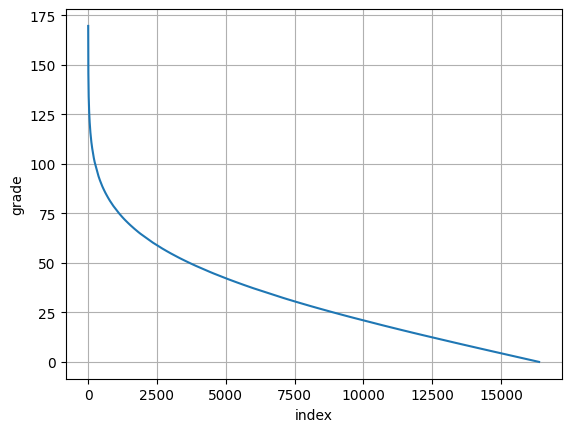

In [41]:
sns.lineplot(a, x='index', y='value', errorbar=None)
plt.xlabel('index')
plt.ylabel('grade')
plt.grid('--')
plt.show()

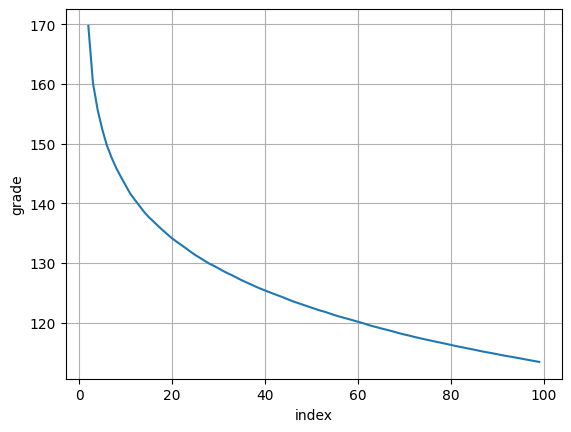

In [42]:
M = 100
b = a[a['index'] < M]
sns.lineplot(b, x='index', y='value', errorbar=None)
plt.xlabel('index')
plt.ylabel('grade')
plt.grid('--')
plt.show()